# Task 3 Updated: Seq2Seq NMT with Hyperparameter Tuning and Embedding Comparison

This notebook is structured as a multi-cell workflow. It addresses the Task 3 requirements:

- RNN-based encoder-decoder sequence-to-sequence model
- train / validation / test split with 20% test set
- manual hyperparameter tuning based on validation loss
- embedding comparison: random embeddings vs GloVe embeddings
- EN → PT and PT → EN translation
- word-level and character-level models
- BLEU and chrF evaluation
- tables and plots for the report

Expected Task 2 outputs:

```text
outputs_task2/clean_sample_10_percent.en
outputs_task2/clean_sample_10_percent.pt
```

Optional GloVe files:

```text
glove/glove.6B.100d.txt
glove/glove.6B.300d.txt
```

If the GloVe files are missing, the corresponding experiments are skipped automatically.

## 1. Imports & Downloads

In [1]:
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict
from typing import List, Tuple, Optional
import random
import math
import time

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:

import urllib.request
import zipfile

PROJECT_DIR = Path.cwd()
GLOVE_DIR = PROJECT_DIR / "glove"
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = GLOVE_DIR / "glove.6B.zip"

if not ZIP_PATH.exists():
    print("Downloading GloVe...")
    urllib.request.urlretrieve(
        "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip",
        ZIP_PATH
    )
    print("Download complete:", ZIP_PATH)
else:
    print("ZIP file already exists:", ZIP_PATH)

required_files = [
    "glove.6B.100d.txt",
    "glove.6B.300d.txt",
]

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    for filename in required_files:
        output_path = GLOVE_DIR / filename

        if output_path.exists():
            print("Already extracted:", output_path)
        else:
            print("Extracting:", filename)
            zip_ref.extract(filename, GLOVE_DIR)

print("\nAvailable files:")
for filename in required_files:
    path = GLOVE_DIR / filename
    print(path, "exists:", path.exists())

ZIP file already exists: /Users/baturu/Desktop/machine_translation/glove/glove.6B.zip
Already extracted: /Users/baturu/Desktop/machine_translation/glove/glove.6B.100d.txt
Already extracted: /Users/baturu/Desktop/machine_translation/glove/glove.6B.300d.txt

Available files:
/Users/baturu/Desktop/machine_translation/glove/glove.6B.100d.txt exists: True
/Users/baturu/Desktop/machine_translation/glove/glove.6B.300d.txt exists: True


## 2. Configuration

In [3]:
try:
    PROJECT_DIR = Path.cwd()
except NameError:
    PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "outputs_task2"
EN_PATH = DATA_DIR / "clean_sample_10_percent.en"
PT_PATH = DATA_DIR / "clean_sample_10_percent.pt"

OUTPUT_DIR = PROJECT_DIR / "outputs_task3_updated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_DIR = PROJECT_DIR / "glove"
GLOVE_100_PATH = GLOVE_DIR / "glove.6B.100d.txt"
GLOVE_300_PATH = GLOVE_DIR / "glove.6B.300d.txt"

RANDOM_SEED = 42
MAX_PAIRS = 30000          # set to None to use all Task 2 sampled pairs
MAX_LEN_WORD = 50
MAX_LEN_CHAR = 250
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5

TUNING_EPOCHS = 2          # short runs for manual tuning
FINAL_EPOCHS = 5           # final word-level experiments
CHAR_EPOCHS = 3            # character-level experiment

PAD = "<pad>"
UNK = "<unk>"
SOS = "<sos>"
EOS = "<eos>"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Project directory:", PROJECT_DIR)
print("EN file:", EN_PATH, EN_PATH.exists())
print("PT file:", PT_PATH, PT_PATH.exists())
print("Output directory:", OUTPUT_DIR)
print("GloVe 100d:", GLOVE_100_PATH, GLOVE_100_PATH.exists())
print("GloVe 300d:", GLOVE_300_PATH, GLOVE_300_PATH.exists())
print("Device:", DEVICE)

Project directory: /Users/baturu/Desktop/machine_translation
EN file: /Users/baturu/Desktop/machine_translation/outputs_task2/clean_sample_10_percent.en True
PT file: /Users/baturu/Desktop/machine_translation/outputs_task2/clean_sample_10_percent.pt True
Output directory: /Users/baturu/Desktop/machine_translation/outputs_task3_updated
GloVe 100d: /Users/baturu/Desktop/machine_translation/glove/glove.6B.100d.txt True
GloVe 300d: /Users/baturu/Desktop/machine_translation/glove/glove.6B.300d.txt True
Device: mps


## 3. Load preprocessed parallel data

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def read_lines(path: Path) -> List[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def load_pairs(en_path: Path, pt_path: Path) -> List[Tuple[str, str]]:
    en = read_lines(en_path)
    pt = read_lines(pt_path)
    assert len(en) == len(pt), "EN and PT files must have the same number of lines."
    return [(e, p) for e, p in zip(en, pt) if e.strip() and p.strip()]

set_seed(RANDOM_SEED)
pairs = load_pairs(EN_PATH, PT_PATH)
if MAX_PAIRS is not None:
    pairs = pairs[:MAX_PAIRS]

print("Loaded sentence pairs:", len(pairs))
print("EN example:", pairs[0][0])
print("PT example:", pairs[0][1])

Loaded sentence pairs: 30000
EN example: this is the obligation on the commission and it must implement the treaties.
PT example: essa é a obrigação da comissão, que tem de implementar os tratados.


## 4. Train / validation / test split

In [5]:
def split_pairs(pairs, test_ratio=0.20, val_ratio=0.10, seed=42):
    rng = random.Random(seed)
    pairs = pairs[:]
    rng.shuffle(pairs)
    n = len(pairs)
    n_test = int(test_ratio * n)
    n_val = int(val_ratio * n)
    test_pairs = pairs[:n_test]
    val_pairs = pairs[n_test:n_test+n_val]
    train_pairs = pairs[n_test+n_val:]
    return train_pairs, val_pairs, test_pairs

train_pairs, val_pairs, test_pairs = split_pairs(pairs, seed=RANDOM_SEED)

split_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "pairs": [len(train_pairs), len(val_pairs), len(test_pairs)],
    "ratio": [len(train_pairs)/len(pairs), len(val_pairs)/len(pairs), len(test_pairs)/len(pairs)]
})
display(split_df)
split_df.to_csv(OUTPUT_DIR / "split_statistics.csv", index=False)

,split,pairs,ratio
0,train,21000,0.7
1,validation,3000,0.1
2,test,6000,0.2


## 5. Tokenizers

In [6]:
def word_tokenize(text: str) -> List[str]:
    return text.strip().split()

def char_tokenize(text: str) -> List[str]:
    return list(text.strip())

print("Word tokens:", word_tokenize(train_pairs[0][0])[:20])
print("Char tokens:", char_tokenize(train_pairs[0][0])[:50])

Word tokens: ['it', 'would,', 'therefore,', 'not', 'surprise', 'me', 'if', 'certain', 'groupings,', 'including', 'in', 'this', 'parliament,', 'were', 'to', 'claim', 'that', 'this', 'agreement', 'does']
Char tokens: ['i', 't', ' ', 'w', 'o', 'u', 'l', 'd', ',', ' ', 't', 'h', 'e', 'r', 'e', 'f', 'o', 'r', 'e', ',', ' ', 'n', 'o', 't', ' ', 's', 'u', 'r', 'p', 'r', 'i', 's', 'e', ' ', 'm', 'e', ' ', 'i', 'f', ' ', 'c', 'e', 'r', 't', 'a', 'i', 'n', ' ', 'g', 'r']


## 6. Vocabulary class

In [7]:
class Vocab:
    def __init__(self, texts, tokenizer, max_size=None, min_freq=1):
        self.tokenizer = tokenizer
        self.specials = [PAD, UNK, SOS, EOS]
        counter = Counter()
        for text in texts:
            counter.update(tokenizer(text))
        tokens = []
        for tok, freq in counter.most_common():
            if freq < min_freq or tok in self.specials:
                continue
            tokens.append(tok)
            if max_size is not None and len(tokens) >= max_size - len(self.specials):
                break
        # itos: index to string
        self.itos = self.specials + tokens
        # stoi: string to index, e.g. "ai":7, "nlp":8
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
        # 保存特殊符号的编号
        self.pad_idx = self.stoi[PAD]
        self.unk_idx = self.stoi[UNK]
        self.sos_idx = self.stoi[SOS]
        self.eos_idx = self.stoi[EOS]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_sos_eos=True):
        ids = [self.stoi.get(tok, self.unk_idx) for tok in self.tokenizer(text)]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids, remove_specials=True):
        tokens = []
        for idx in ids:
            tok = self.itos[idx] if 0 <= idx < len(self.itos) else UNK
            if remove_specials and tok in {PAD, SOS, EOS}:
                continue
            tokens.append(tok)
        return tokens

## 7. Dataset and DataLoader

In [8]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, max_len, tokenizer_type="word"):
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len
        self.tokenizer_type = tokenizer_type
        self.examples = []
        for src, trg in pairs:
            if tokenizer_type == "word":
                if len(word_tokenize(src)) > max_len or len(word_tokenize(trg)) > max_len:
                    continue
            else:
                if len(char_tokenize(src)) > max_len or len(char_tokenize(trg)) > max_len:
                    continue
            self.examples.append((src, trg))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        src, trg = self.examples[idx]
        return (
            torch.tensor(self.src_vocab.encode(src), dtype=torch.long),
            torch.tensor(self.trg_vocab.encode(trg), dtype=torch.long)
        )

def make_collate_fn(src_pad_idx, trg_pad_idx):
    def collate_fn(batch):
        src_batch, trg_batch = zip(*batch)
        max_src_len = max(len(x) for x in src_batch)
        max_trg_len = max(len(x) for x in trg_batch)
        padded_src = torch.full((len(batch), max_src_len), src_pad_idx, dtype=torch.long)
        padded_trg = torch.full((len(batch), max_trg_len), trg_pad_idx, dtype=torch.long)
        for i, (src, trg) in enumerate(zip(src_batch, trg_batch)):
            padded_src[i, :len(src)] = src
            padded_trg[i, :len(trg)] = trg
        return padded_src, padded_trg
    return collate_fn

## 8. GloVe embedding loader

In [9]:
def load_glove_vectors(glove_path: Path, expected_dim: int, vocab: Vocab):
    """Load only vectors needed for the current vocabulary."""
    if not glove_path.exists():
        print(f"Missing GloVe file: {glove_path}. Skipping this embedding experiment.")
        return None

    print("Loading:", glove_path)
    vocab_words = set(vocab.stoi.keys())
    vectors = {}

    with open(glove_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            # GloVe 文件长这样：
            # the 0.418 0.24968 ...
            # cat -0.57 0.13 ...
            # 一行就是一个单词。
            parts = line.rstrip().split(" ")
            word = parts[0]
            if word not in vocab_words:
                continue

            values = parts[1:]
            if len(values) != expected_dim:
                continue
            vectors[word] = torch.tensor([float(x) for x in values], dtype=torch.float)

    matrix = torch.empty(len(vocab), expected_dim)
    nn.init.normal_(matrix, mean=0.0, std=0.1)
    matrix[vocab.pad_idx].zero_()

    covered = 0
    for word, idx in vocab.stoi.items():
        if word in vectors:
            matrix[idx] = vectors[word]
            covered += 1

    print(f"Coverage: {covered}/{len(vocab)} = {covered / max(1, len(vocab)) * 100:.2f}%")
    return matrix

## 9. RNN-based encoder-decoder Seq2Seq model

In [10]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout, pad_idx,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            assert pretrained_embeddings.shape == self.embedding.weight.data.shape
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embeddings
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, pad_idx,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            assert pretrained_embeddings.shape == self.embedding.weight.data.shape
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embeddings
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        hidden, cell = self.encoder(src)
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if teacher_force else output.argmax(1)
        return outputs

## 10. Training and validation functions

In [11]:
def train_epoch(model, dataloader, optimizer, 
                criterion, clip, 
                teacher_forcing_ratio):
    model.train()
    epoch_loss = 0
    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / max(1, len(dataloader))

@torch.no_grad()
def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)
        output = model(src, trg, teacher_forcing_ratio=0.0)
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        epoch_loss += loss.item()
    return epoch_loss / max(1, len(dataloader))

## 11. Translation, BLEU, and chrF

In [12]:
@torch.no_grad()
def translate_sentence(model, sentence, src_vocab, trg_vocab, max_output_len=80):
    model.eval()
    src_ids = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    hidden, cell = model.encoder(src_tensor)
    input_token = torch.tensor([trg_vocab.sos_idx], dtype=torch.long).to(DEVICE)
    output_ids = []
    for _ in range(max_output_len):
        output, hidden, cell = model.decoder(input_token, hidden, cell)
        pred_id = output.argmax(1).item()
        if pred_id == trg_vocab.eos_idx:
            break
        output_ids.append(pred_id)
        input_token = torch.tensor([pred_id], dtype=torch.long).to(DEVICE)
    return trg_vocab.decode(output_ids)

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def corpus_bleu(references, hypotheses, max_n=4):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_len = 0
    hyp_len = 0
    for ref, hyp in zip(references, hypotheses):
        ref_len += len(ref)
        hyp_len += len(hyp)
        for n in range(1, max_n + 1):
            ref_counts = Counter(ngrams(ref, n))
            hyp_counts = Counter(ngrams(hyp, n))
            total_counts[n-1] += sum(hyp_counts.values())
            for gram, count in hyp_counts.items():
                clipped_counts[n-1] += min(count, ref_counts.get(gram, 0))
    precisions = [(c + 1) / (t + 1) for c, t in zip(clipped_counts, total_counts)]
    if hyp_len == 0:
        return 0.0
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(1, hyp_len))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n) * 100

def char_ngrams(text, n):
    return [text[i:i+n] for i in range(len(text)-n+1)]

def sentence_chrf(reference, hypothesis, max_n=6, beta=2.0):
    scores = []
    for n in range(1, max_n + 1):
        ref_counts = Counter(char_ngrams(reference, n))
        hyp_counts = Counter(char_ngrams(hypothesis, n))
        overlap = sum(min(count, ref_counts.get(g, 0)) for g, count in hyp_counts.items())
        precision = overlap / max(1, sum(hyp_counts.values()))
        recall = overlap / max(1, sum(ref_counts.values()))
        if precision == 0 and recall == 0:
            scores.append(0.0)
        else:
            scores.append((1 + beta**2) * precision * recall / (beta**2 * precision + recall))
    return sum(scores) / len(scores) * 100

def corpus_chrf(reference_texts, hypothesis_texts):
    return sum(sentence_chrf(r, h) for r, h in zip(reference_texts, hypothesis_texts)) / max(1, len(reference_texts))

@torch.no_grad()
def evaluate_translation_metrics(model, test_examples, src_vocab, trg_vocab, tokenizer_type="word", max_examples=500):
    eval_examples = test_examples[:max_examples]
    joiner = "" if tokenizer_type == "char" else " "
    references_tokens, hypotheses_tokens = [], []
    references_text, hypotheses_text = [], []
    max_output_len = 250 if tokenizer_type == "char" else 80
    for src, ref in eval_examples:
        hyp_tokens = translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=max_output_len)
        ref_tokens = char_tokenize(ref) if tokenizer_type == "char" else word_tokenize(ref)
        references_tokens.append(ref_tokens)
        hypotheses_tokens.append(hyp_tokens)
        references_text.append(ref)
        hypotheses_text.append(joiner.join(hyp_tokens))
    return corpus_bleu(references_tokens, hypotheses_tokens), corpus_chrf(references_text, hypotheses_text), references_text, hypotheses_text

## 12. Experiment configuration and runner

In [13]:
@dataclass
class ExperimentConfig:
    name: str
    src_lang: str
    trg_lang: str
    tokenizer_type: str = "word"
    embedding_type: str = "random"  # random, glove100, glove300
    emb_dim: int = 256
    hid_dim: int = 512
    dropout: float = 0.3
    num_epochs: int = 5
    freeze_embeddings: bool = False

def make_direction_pairs(all_pairs, src_lang, trg_lang):
    if src_lang == "en" and trg_lang == "pt":
        return all_pairs
    if src_lang == "pt" and trg_lang == "en":
        return [(pt, en) for en, pt in all_pairs]
    raise ValueError("Only en→pt and pt→en are supported.")

def build_data_for_config(config, all_pairs):
    exp_pairs = make_direction_pairs(all_pairs, config.src_lang, config.trg_lang)
    train_p, val_p, test_p = split_pairs(exp_pairs, seed=RANDOM_SEED)
    tokenizer = word_tokenize if config.tokenizer_type == "word" else char_tokenize
    max_len = MAX_LEN_WORD if config.tokenizer_type == "word" else MAX_LEN_CHAR
    max_vocab = MAX_VOCAB_SIZE if config.tokenizer_type == "word" else None
    min_freq = MIN_FREQ if config.tokenizer_type == "word" else 1
    src_vocab = Vocab([src for src, _ in train_p], tokenizer, max_size=max_vocab, min_freq=min_freq)
    trg_vocab = Vocab([trg for _, trg in train_p], tokenizer, max_size=max_vocab, min_freq=min_freq)
    train_data = TranslationDataset(train_p, src_vocab, trg_vocab, max_len=max_len, tokenizer_type=config.tokenizer_type)
    val_data = TranslationDataset(val_p, src_vocab, trg_vocab, max_len=max_len, tokenizer_type=config.tokenizer_type)
    test_data = TranslationDataset(test_p, src_vocab, trg_vocab, max_len=max_len, tokenizer_type=config.tokenizer_type)
    collate_fn = make_collate_fn(src_vocab.pad_idx, trg_vocab.pad_idx)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    return src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader

def get_embedding_matrices(config, src_vocab, trg_vocab):
    if config.embedding_type == "random":
        return None, None
    if config.embedding_type == "glove100":
        path, dim = GLOVE_100_PATH, 100
    elif config.embedding_type == "glove300":
        path, dim = GLOVE_300_PATH, 300
    else:
        raise ValueError(config.embedding_type)
    if config.emb_dim != dim:
        raise ValueError(f"{config.embedding_type} requires emb_dim={dim}")
    src_matrix = load_glove_vectors(path, dim, src_vocab)
    trg_matrix = load_glove_vectors(path, dim, trg_vocab)
    return src_matrix, trg_matrix

def create_model_from_config(config, src_vocab, trg_vocab):
    src_matrix, trg_matrix = get_embedding_matrices(config, src_vocab, trg_vocab)
    if config.embedding_type.startswith("glove") and (src_matrix is None or trg_matrix is None):
        return None
    encoder = Encoder(len(src_vocab), config.emb_dim, config.hid_dim, config.dropout, src_vocab.pad_idx,
                      pretrained_embeddings=src_matrix, freeze_embeddings=config.freeze_embeddings)
    decoder = Decoder(len(trg_vocab), config.emb_dim, config.hid_dim, config.dropout, trg_vocab.pad_idx,
                      pretrained_embeddings=trg_matrix, freeze_embeddings=config.freeze_embeddings)
    return Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

def run_experiment(config, all_pairs, save_predictions=True):
    print("\n" + "=" * 100)
    print(config)
    print("=" * 100)
    set_seed(RANDOM_SEED)
    src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader = build_data_for_config(config, all_pairs)
    print("src vocab:", len(src_vocab), "trg vocab:", len(trg_vocab))
    print("train:", len(train_data), "val:", len(val_data), "test:", len(test_data))
    model = create_model_from_config(config, src_vocab, trg_vocab)
    if model is None:
        print("Skipped because the required embedding file is missing.")
        return None
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)
    history, best_val_loss = [], float("inf")
    best_path = OUTPUT_DIR / f"{config.name}_best.pt"
    for epoch in range(1, config.num_epochs + 1):
        start = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
        val_loss = evaluate_loss(model, val_loader, criterion)
        elapsed = time.time() - start
        row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
               "train_ppl": math.exp(min(train_loss, 20)), "val_ppl": math.exp(min(val_loss, 20)),
               "time_sec": elapsed}
        history.append(row)
        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | time {elapsed:.1f}s")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    bleu, chrf, refs, hyps = evaluate_translation_metrics(model, test_data.examples, src_vocab, trg_vocab, tokenizer_type=config.tokenizer_type)
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{config.name}_history.csv", index=False)
    pred_path = ""
    if save_predictions:
        pred_path = OUTPUT_DIR / f"{config.name}_sample_predictions.txt"
        with open(pred_path, "w", encoding="utf-8") as f:
            for i, ((src, ref), hyp) in enumerate(zip(test_data.examples[:50], hyps[:50]), start=1):
                f.write(f"Example {i}\nSRC: {src}\nREF: {ref}\nHYP: {hyp}\n" + "-" * 80 + "\n")
    result = {**asdict(config), "src_vocab_size": len(src_vocab), "trg_vocab_size": len(trg_vocab),
              "train_examples": len(train_data), "val_examples": len(val_data), "test_examples": len(test_data),
              "best_val_loss": best_val_loss, "test_bleu": bleu, "test_chrf": chrf,
              "best_model_path": str(best_path), "prediction_path": str(pred_path)}
    print("Test BLEU:", round(bleu, 2), "Test chrF:", round(chrf, 2))
    return {"config": config, "model": model, "src_vocab": src_vocab, "trg_vocab": trg_vocab,
            "test_data": test_data, "history_df": history_df, "result": result}

## 13. Manual hyperparameter tuning

In [14]:
tuning_configs = [
    ExperimentConfig("tune_random_small", "en", "pt", "word", "random", emb_dim=128, hid_dim=256, dropout=0.3, num_epochs=TUNING_EPOCHS),
    ExperimentConfig("tune_random_base", "en", "pt", "word", "random", emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=TUNING_EPOCHS),
    ExperimentConfig("tune_random_base_dropout05", "en", "pt", "word", "random", emb_dim=256, hid_dim=512, dropout=0.5, num_epochs=TUNING_EPOCHS),
]

tuning_outputs = []
for cfg in tuning_configs:
    out = run_experiment(cfg, pairs, save_predictions=False)
    if out is not None:
        tuning_outputs.append(out)

tuning_df = pd.DataFrame([x["result"] for x in tuning_outputs])
display(tuning_df[["name", "emb_dim", "hid_dim", "dropout", "best_val_loss", "test_bleu", "test_chrf"]])
tuning_df.to_csv(OUTPUT_DIR / "manual_hyperparameter_tuning_results.csv", index=False)

best_tuning_row = tuning_df.sort_values("best_val_loss").iloc[0]
print("Selected by lowest validation loss:")
display(best_tuning_row)


ExperimentConfig(name='tune_random_small', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=128, hid_dim=256, dropout=0.3, num_epochs=2, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.8955 | val loss 6.5320 | time 262.4s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/tune_random_small_best.pt
Epoch 02 | train loss 6.4353 | val loss 6.4832 | time 252.8s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/tune_random_small_best.pt
Test BLEU: 0.23 Test chrF: 10.22

ExperimentConfig(name='tune_random_base', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=2, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.7698 | val loss 6.5426 | time 343.6s
Saved best model: /Users/baturu/D

,name,emb_dim,hid_dim,dropout,best_val_loss,test_bleu,test_chrf
0,tune_random_small,128,256,0.3,6.483250,0.229031,10.218436
1,tune_random_base,256,512,0.3,6.467726,0.225855,10.178954
2,tune_random_base_dropout05,256,512,0.5,6.528271,0.081720,5.154336


Selected by lowest validation loss:


name                                                  tune_random_base
src_lang                                                            en
trg_lang                                                            pt
tokenizer_type                                                    word
embedding_type                                                  random
emb_dim                                                            256
hid_dim                                                            512
dropout                                                            0.3
num_epochs                                                           2
freeze_embeddings                                                False
src_vocab_size                                                   14457
trg_vocab_size                                                   18693
train_examples                                                   19424
val_examples                                                      2785
test_e

## 14. Plot manual tuning results

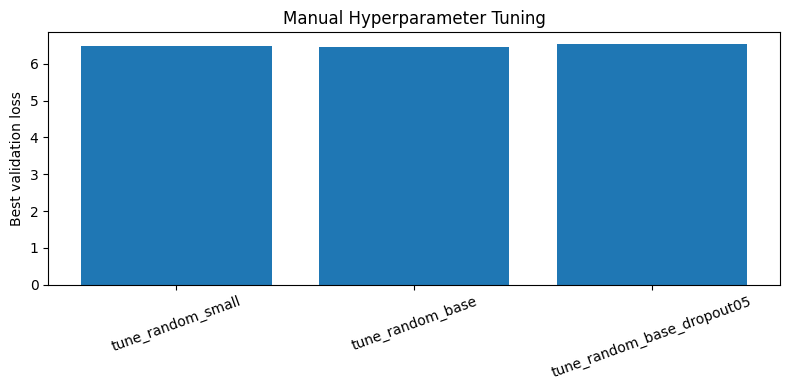

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(tuning_df["name"], tuning_df["best_val_loss"])
plt.ylabel("Best validation loss")
plt.title("Manual Hyperparameter Tuning")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "manual_tuning_val_loss.png", dpi=200)
plt.show()

## 15. Final random-embedding EN → PT baseline

In [16]:
best_emb_dim = int(best_tuning_row["emb_dim"])
best_hid_dim = int(best_tuning_row["hid_dim"])
best_dropout = float(best_tuning_row["dropout"])

final_random_config = ExperimentConfig(
    name="final_word_en_to_pt_random",
    src_lang="en",
    trg_lang="pt",
    tokenizer_type="word",
    embedding_type="random",
    emb_dim=best_emb_dim,
    hid_dim=best_hid_dim,
    dropout=best_dropout,
    num_epochs=FINAL_EPOCHS
)
final_random_output = run_experiment(final_random_config, pairs, save_predictions=True)


ExperimentConfig(name='final_word_en_to_pt_random', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.7692 | val loss 6.5373 | time 325.2s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_random_best.pt
Epoch 02 | train loss 6.2713 | val loss 6.4712 | time 338.7s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_random_best.pt
Epoch 03 | train loss 6.0290 | val loss 6.4404 | time 337.7s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_random_best.pt
Epoch 04 | train loss 5.8697 | val loss 6.3592 | time 336.0s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_random_best.pt
Epoch 05 | 

## 16. Final GloVe 100d EN → PT experiment

In [17]:
glove100_config = ExperimentConfig(
    name="final_word_en_to_pt_glove100",
    src_lang="en",
    trg_lang="pt",
    tokenizer_type="word",
    embedding_type="glove100",
    emb_dim=100,
    hid_dim=best_hid_dim,
    dropout=best_dropout,
    num_epochs=FINAL_EPOCHS,
    freeze_embeddings=False
)
glove100_output = run_experiment(glove100_config, pairs, save_predictions=True)


ExperimentConfig(name='final_word_en_to_pt_glove100', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='glove100', emb_dim=100, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Loading: /Users/baturu/Desktop/machine_translation/glove/glove.6B.100d.txt
Coverage: 9108/14457 = 63.00%
Loading: /Users/baturu/Desktop/machine_translation/glove/glove.6B.100d.txt
Coverage: 2866/18693 = 15.33%
Epoch 01 | train loss 6.7742 | val loss 6.4884 | time 322.9s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_glove100_best.pt
Epoch 02 | train loss 6.3172 | val loss 6.4485 | time 312.7s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_glove100_best.pt
Epoch 03 | train loss 6.0658 | val loss 6.3853 | time 1250.1s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final

## 17. Optional GloVe 300d EN → PT experiment

In [18]:
glove300_config = ExperimentConfig(
    name="final_word_en_to_pt_glove300",
    src_lang="en",
    trg_lang="pt",
    tokenizer_type="word",
    embedding_type="glove300",
    emb_dim=300,
    hid_dim=best_hid_dim,
    dropout=best_dropout,
    num_epochs=FINAL_EPOCHS,
    freeze_embeddings=False
)
glove300_output = run_experiment(glove300_config, pairs, save_predictions=True)


ExperimentConfig(name='final_word_en_to_pt_glove300', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='glove300', emb_dim=300, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Loading: /Users/baturu/Desktop/machine_translation/glove/glove.6B.300d.txt
Coverage: 9108/14457 = 63.00%
Loading: /Users/baturu/Desktop/machine_translation/glove/glove.6B.300d.txt
Coverage: 2866/18693 = 15.33%
Epoch 01 | train loss 6.7356 | val loss 6.4985 | time 372.9s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_glove300_best.pt
Epoch 02 | train loss 6.2146 | val loss 6.4627 | time 385.5s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_en_to_pt_glove300_best.pt
Epoch 03 | train loss 5.9663 | val loss 6.3998 | time 385.3s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_

## 18. Reverse translation: PT → EN

Change your input and target languages (Translate from Portuguese to English) and train your mode again o Compare the results in this step with the results from the previous step where English was the input language.

In [ ]:
reverse_config = ExperimentConfig(
    name="final_word_pt_to_en_random",
    src_lang="pt",
    trg_lang="en",
    tokenizer_type="word",
    embedding_type="random",
    emb_dim=best_emb_dim,
    hid_dim=best_hid_dim,
    dropout=best_dropout,
    num_epochs=FINAL_EPOCHS
)
reverse_output = run_experiment(reverse_config, pairs, save_predictions=True)


ExperimentConfig(name='final_word_pt_to_en_random', src_lang='pt', trg_lang='en', tokenizer_type='word', embedding_type='random', emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 18693 trg vocab: 14457
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.4306 | val loss 6.3396 | time 284.1s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_updated/final_word_pt_to_en_random_best.pt


## 19. Character-level EN → PT model

Develop a character-based model that trains to translate characters into the target language.  
Compare the results by this model with the achieved results from the word-based models before.

In [ ]:
char_config = ExperimentConfig(
    name="final_char_en_to_pt_random",
    src_lang="en",
    trg_lang="pt",
    tokenizer_type="char",
    embedding_type="random",
    emb_dim=128,
    hid_dim=256,
    dropout=best_dropout,
    num_epochs=CHAR_EPOCHS
)
char_output = run_experiment(char_config, pairs, save_predictions=True)

## 20. Final results summary

In [ ]:
all_outputs = [final_random_output, glove100_output, glove300_output, reverse_output, char_output]
final_results = [x["result"] for x in all_outputs if x is not None]
final_results_df = pd.DataFrame(final_results)

display(final_results_df[[
    "name", "src_lang", "trg_lang", "tokenizer_type", "embedding_type",
    "emb_dim", "hid_dim", "dropout", "best_val_loss", "test_bleu", "test_chrf"
]])

final_results_df.to_csv(OUTPUT_DIR / "final_task3_results_summary.csv", index=False)

## 21. Embedding impact comparison

In [ ]:
embedding_comparison_df = final_results_df[
    (final_results_df["src_lang"] == "en") &
    (final_results_df["trg_lang"] == "pt") &
    (final_results_df["tokenizer_type"] == "word")
].copy()

display(embedding_comparison_df[["name", "embedding_type", "emb_dim", "best_val_loss", "test_bleu", "test_chrf"]])
embedding_comparison_df.to_csv(OUTPUT_DIR / "embedding_comparison_results.csv", index=False)

if len(embedding_comparison_df) > 0:
    plt.figure(figsize=(7, 4))
    plt.bar(embedding_comparison_df["embedding_type"], embedding_comparison_df["test_bleu"])
    plt.ylabel("BLEU")
    plt.title("Impact of Embedding Models on BLEU")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "embedding_comparison_bleu.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(embedding_comparison_df["embedding_type"], embedding_comparison_df["test_chrf"])
    plt.ylabel("chrF")
    plt.title("Impact of Embedding Models on chrF")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "embedding_comparison_chrf.png", dpi=200)
    plt.show()

## 22. Direction comparison: EN → PT vs PT → EN

In [ ]:
direction_comparison_df = final_results_df[
    (final_results_df["tokenizer_type"] == "word") &
    (final_results_df["embedding_type"] == "random")
].copy()

display(direction_comparison_df[["name", "src_lang", "trg_lang", "best_val_loss", "test_bleu", "test_chrf"]])
direction_comparison_df.to_csv(OUTPUT_DIR / "direction_comparison_results.csv", index=False)

## 23. Word-level vs character-level comparison

In [ ]:
level_comparison_df = final_results_df[
    (final_results_df["src_lang"] == "en") &
    (final_results_df["trg_lang"] == "pt") &
    (final_results_df["embedding_type"] == "random")
].copy()

display(level_comparison_df[["name", "tokenizer_type", "best_val_loss", "test_bleu", "test_chrf"]])
level_comparison_df.to_csv(OUTPUT_DIR / "word_vs_char_results.csv", index=False)

## 24. Qualitative translation examples

In [ ]:
if final_random_output is not None:
    model = final_random_output["model"]
    src_vocab = final_random_output["src_vocab"]
    trg_vocab = final_random_output["trg_vocab"]
    test_data = final_random_output["test_data"]

    for i in range(5):
        src, ref = test_data.examples[i]
        hyp = " ".join(translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=80))
        print(f"Example {i+1}")
        print("SRC:", src)
        print("REF:", ref)
        print("HYP:", hyp)
        print("-" * 80)

## 25. Sentence length impact analysis

In [ ]:
if final_random_output is not None:
    model = final_random_output["model"]
    src_vocab = final_random_output["src_vocab"]
    trg_vocab = final_random_output["trg_vocab"]
    test_data = final_random_output["test_data"]

    rows = []
    for src, ref in test_data.examples[:300]:
        hyp = " ".join(translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=80))
        rows.append({
            "src_length": len(word_tokenize(src)),
            "chrf": sentence_chrf(ref, hyp),
            "src": src,
            "ref": ref,
            "hyp": hyp
        })

    length_impact_df = pd.DataFrame(rows)
    display(length_impact_df[["src_length", "chrf"]].describe())

    plt.figure(figsize=(7, 4))
    plt.scatter(length_impact_df["src_length"], length_impact_df["chrf"], alpha=0.5)
    plt.xlabel("Source sentence length")
    plt.ylabel("Sentence-level chrF")
    plt.title("Impact of Source Sentence Length on Translation Quality")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "length_vs_chrf.png", dpi=200)
    plt.show()

    length_impact_df.to_csv(OUTPUT_DIR / "length_impact_analysis.csv", index=False)

## 26. Report text templates

### Hyperparameter tuning

> We performed manual hyperparameter tuning using the validation set. Three configurations were compared by varying the embedding dimension, LSTM hidden dimension, and dropout rate. Each configuration was trained for a small number of epochs, and the configuration with the lowest validation loss was selected for the final experiments. Manual tuning was chosen instead of exhaustive grid search because neural machine translation training is computationally expensive.

### Embedding comparison

> To analyze the impact of different embedding models, we compared randomly initialized embeddings with pretrained GloVe embeddings. Random embeddings were learned from scratch during model training, while GloVe initialized the embedding layers with pretrained word vectors. The models were compared using validation loss, BLEU, and chrF.

### Encoder-decoder architecture

> The model is an RNN-based sequence-to-sequence architecture with an LSTM encoder and an LSTM decoder. The encoder maps the source sentence into hidden and cell states. These states initialize the decoder, which generates the target sentence token by token. Teacher forcing was used during training.

### Direction and character-level comparison

> We trained the model for both English-to-Portuguese and Portuguese-to-English translation. We also trained a character-level model in which the vocabulary consists of characters instead of words. This allows a comparison between word-level and character-level translation under the same encoder-decoder framework.